# Plot comparison of the dynamic rupture simulation

2025.1.6 Kurama Okubo


In [1]:
import os
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
import matplotlib.colors as colors
import matplotlib as mpl

%matplotlib inline
import numpy as np
import pandas as pd
import datetime
from datetime import timedelta
from tqdm import tqdm
import warnings
import time

from importParaviewColormap import importParaviewColormap
import seaborn as sns
from matplotlib.collections import LineCollection

%load_ext autoreload
%autoreload 2


plt.rcParams["font.family"] = 'Arial'
# plt.rcParams["font.sans-serif"] = "DejaVu Sans, Arial, Helvetica, Lucida Grande, Verdana, Geneva, Lucid, Avant Garde, sans-serif"
plt.rcParams["font.size"] = 10
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["xtick.major.size"] = 4.75
plt.rcParams["xtick.major.width"] = 0.75
plt.rcParams["xtick.minor.size"] = 3
plt.rcParams["xtick.minor.width"] = 0.4
plt.rcParams["xtick.minor.visible"] = True

plt.rcParams["ytick.direction"] = "in"
plt.rcParams["ytick.major.size"] = 4.75
plt.rcParams["ytick.major.width"] = 0.75
plt.rcParams["ytick.minor.size"] = 3
plt.rcParams["ytick.minor.width"] = 0.4
plt.rcParams["ytick.minor.visible"] = True

plt.rcParams["savefig.transparent"] = True

plt.rcParams['axes.linewidth'] = 0.75

In [2]:
figdir = "../figure/aux03_comparison_healing"
if not os.path.exists(figdir):
    os.makedirs(figdir)

In [3]:
E = 96e9
nu = 0.246 # metagabbro
mu = E/(2*(1+nu))

a_patch = 4.0e-3
a_nuc = 2.5e-3 # nucleation radius 

nb_x_elements = 1024 #128 #1024
nb_z_elements = 1024 #128 #1024


Ifmasteroutput=True # add file key to the master output
if Ifmasteroutput:
    filekey = "_master"
else:
    filekey = ""

In [4]:
# case study parameter casename

a_patch = 4.0e-3
a_nuc = 2.5e-3
a_margin = 4.08e-3

rupturetype = "pulse"
pdcscaling = 0.60 #0.65
bgbeta= 0.35 #0.4

sig_n = 6e6

IfBinaryOutput = True

casestr = f"a={a_patch*1e3:.2f}_ruptype={rupturetype}_pdcscaling={pdcscaling:.3f}_sn={sig_n/1e6:.1f}MPa_hatfr=0.3_bgbeta={bgbeta:.2f}"

simulation_rootdir="../../../RuptureSimulation/main_casestudy/postprocess_dynrup/code/"
finame=simulation_rootdir+f"../../preprocess_modelsetup/data/gouge_dynamicrupture_modelparam_{casestr}{filekey}.csv"

# Read model parameters
df_modelparam = pd.read_csv(finame, index_col=0)

datadir_root = "/Volumes/Okuboetal2025_masterHDD/RuptureSimulation/main_casestudy/build_hpcv65_diffcheck_mastercase_v4/simulations_main_casestudy_hpc_master"
# datadir_root="/Users/kokubo/Dropbox/NIED_RESEARCH/4mBIAX_submission/4mNonSelfSim_UGUCA/build_example_macmini/example_4mNonSelfSim"
casestr

'a=4.00_ruptype=pulse_pdcscaling=0.600_sn=6.0MPa_hatfr=0.3_bgbeta=0.35'

In [5]:
df_modelparam.head()

,M0_mean,Tw_mean,Mw_mean,hat_sn_patch,hat_sn_background,delsig_withmargin_try,slip_try,initialstress_fraction,delsigma_factor,fp_patch,...,GIIC_patch,GIIC_background,Sratio_nuc,Sratio_patch,Ainit_nuc,Ainit_patch,Anuc_nuc,Anuc_patch,rnuc_nuc,rnuc_patch
gougeevent_id,,,,,,,,,,,,,,,,,,,,,
4,0.594031,0.000003,-6.220794,6000000.0,2000000.0,3826544.690,2.948600e-07,0.925,0.6,0.738005,...,0.063683,0.0,0,0.144648,3.82,3.827647,0.000002,0.000002,0.783375,0.784159
9,0.047135,0.000002,-6.954435,6000000.0,2000000.0,303630.180,2.339667e-08,0.925,0.6,0.357149,...,0.001817,0.0,0,0.882198,3.82,5.050491,0.000005,0.000007,1.312687,1.509373
18,0.757592,0.000003,-6.150376,6000000.0,2000000.0,4880150.680,3.760471e-07,0.925,0.6,0.851908,...,0.092850,0.0,0,0.130924,3.82,3.825779,0.000002,0.000002,0.719379,0.719923
19,0.056071,0.000002,-6.904172,6000000.0,2000000.0,361193.127,2.783226e-08,0.925,0.6,0.363372,...,0.002236,0.0,0,0.754525,3.82,4.613050,0.000005,0.000007,1.313740,1.443683
20,0.867075,0.000003,-6.111295,6000000.0,2000000.0,5585402.460,4.303913e-07,0.925,0.6,0.928152,...,0.114592,0.0,0,0.124631,3.82,3.825032,0.000001,0.000001,0.685382,0.685833


# Plot comparison between target events

We plot displacement and shear stress change at final snap shots to compare the slip area limited by self-healing.

Process 24: fb03-087__0024_a=4.00_ruptype=pulse_pdcscaling=0.600_sn=6.0MPa_hatfr=0.3_bgbeta=0.35_0.6950
Grid size: 0.0390625[mm]
maximum slip is 0.048305μm
Ds within patch is 0.07 μm
Process 50: fb03-087__0050_a=4.00_ruptype=pulse_pdcscaling=0.600_sn=6.0MPa_hatfr=0.3_bgbeta=0.35_0.4950
Grid size: 0.0390625[mm]
maximum slip is 0.183255μm
Ds within patch is 0.19 μm
Process 52: fb03-087__0052_a=4.00_ruptype=pulse_pdcscaling=0.600_sn=6.0MPa_hatfr=0.3_bgbeta=0.35_0.4600
Grid size: 0.0390625[mm]
maximum slip is 0.236529μm
Ds within patch is 0.24 μm
Process 72: fb03-087__0072_a=4.00_ruptype=pulse_pdcscaling=0.600_sn=6.0MPa_hatfr=0.3_bgbeta=0.35_0.4300
Grid size: 0.0390625[mm]
maximum slip is 0.324131μm
Ds within patch is 0.32 μm
Process 129: fb03-087__0129_a=4.00_ruptype=pulse_pdcscaling=0.600_sn=6.0MPa_hatfr=0.3_bgbeta=0.35_0.4100
Grid size: 0.0390625[mm]
maximum slip is 0.397012μm
Ds within patch is 0.39 μm


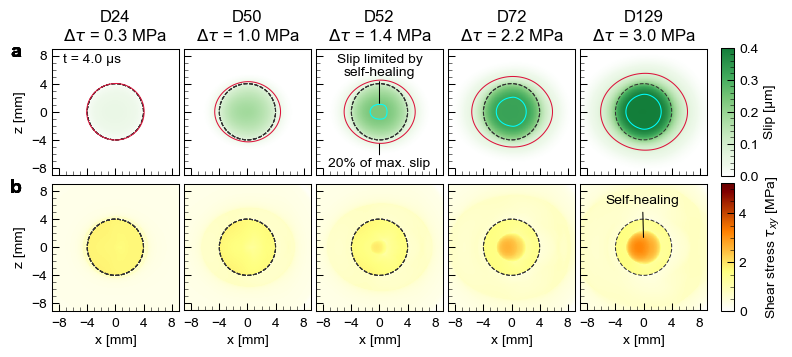

In [6]:
# Select gouge event id to plot the snapshots
expr_id = 87
# gougeevent_id = 129 # 24, 50, 52, 72, 129
target_event_ids = [24, 50, 52, 72, 129] #[129, 129, 129, 129, 129] #[24, 50, 52, 72, 129]

rightmargin = 0.005
colorbargridwidth = 0.02
width_ratios = np.hstack([np.ones(len(target_event_ids))*(1-(rightmargin+colorbargridwidth))/len(target_event_ids), rightmargin, colorbargridwidth])

t_snapshot_comparison = 4.0e-6 # timing at which the slip and shear stress are compared

fig, axs = plt.subplots(2, len(target_event_ids)+2, figsize=(8.8, 3.42), gridspec_kw={'width_ratios': width_ratios})
fig.subplots_adjust(wspace=0.06, hspace=0.06)
    
for icase, gougeevent_id in enumerate(target_event_ids):

    # if icase != 4: # for Debug
    #     continue
        
    df_modelparam_selected = df_modelparam[df_modelparam.index == gougeevent_id]
    
    # if ifParamStudy:
    simulation_name = f"fb03-{expr_id:03d}__{df_modelparam_selected.index[0]:04d}_{casestr}_{df_modelparam_selected.delsigma_factor.values[0]:.4f}"
    # else:
        # simulation_name = f"fb03-{expr_id:03d}__{df_modelparam_selected.index[0]:04d}_{casestr}"
            
    # simulation_name = f"{expr_id}__{df_modelparam_selected.index[0]:04d}_{casestr}"
    
    print(f"Process {gougeevent_id}: {simulation_name}")
    
    # Plot snapshots of the dynamic rupture simulation
    
    ## Set the model parameters
    
    df_time = pd.read_csv(os.path.join(datadir_root,simulation_name+".time"), header=None, sep=' ', index_col=0)
    df_coord = pd.read_csv(os.path.join(datadir_root,simulation_name+".coords"), header=None, sep=' ', index_col=None)
    NT=len(df_time)
    
    
    # location of the center of nucleation zone
    nuc_x = -(a_patch - a_nuc)
    nuc_z = 0
    
    xcoord = df_coord.loc[:,0].values
    zcoord = df_coord.loc[:,2].values
    
    x_length = xcoord.max()
    z_length = zcoord.max()
    
    # ref also: https://stackoverflow.com/a/35176314
    dgrid = (zcoord[1] - zcoord[0])
    print(f"Grid size: {dgrid*1e3}[mm]") 
    
    X = xcoord.reshape(nb_x_elements,nb_z_elements).T- dgrid/2 - x_length/2
    Z = zcoord.reshape(nb_x_elements,nb_z_elements).T- dgrid/2 - z_length/2
    
    ## Read data
    
    read_comp = 0 #0: Mode II direction, 1: normal (Mode I), 2:Mode III direction 
    
    # read velocity
    read_parameter = f"top_velo_{read_comp}" # select the parameter to read
    if IfBinaryOutput:
        D = np.fromfile(os.path.join(datadir_root,simulation_name+f"-DataFiles/{read_parameter}.out"), dtype="float32")
        df_data_vel = pd.DataFrame(data=D.reshape((NT, -1)))
    else:
        df_data_vel = pd.read_csv(os.path.join(datadir_root,simulation_name+f"-DataFiles/{read_parameter}.out"), header=None, sep=' ', engine="c")
        
    # read displacement
    read_parameter = f"top_disp_{read_comp}" # select the parameter to read
    if IfBinaryOutput:
        D = np.fromfile(os.path.join(datadir_root,simulation_name+f"-DataFiles/{read_parameter}.out"), dtype="float32")
        df_data_disp = pd.DataFrame(data=D.reshape((NT, -1)))
    else:
        df_data_disp = pd.read_csv(os.path.join(datadir_root,simulation_name+f"-DataFiles/{read_parameter}.out"), header=None, sep=' ', engine="c")
    
    # read cohesion (shear traction)
    read_parameter = f"cohesion_{read_comp}" # select the parameter to read
    if IfBinaryOutput:
        D = np.fromfile(os.path.join(datadir_root,simulation_name+f"-DataFiles/{read_parameter}.out"), dtype="float32")
        df_data_coh = pd.DataFrame(data=D.reshape((NT, -1)))
    else:
        df_data_coh = pd.read_csv(os.path.join(datadir_root,simulation_name+f"-DataFiles/{read_parameter}.out"), header=None, sep=' ', engine="c")
    
    
    # check if the grid size is consistent to the data shape
    assert len(df_data_vel.columns) == len(xcoord)
    assert len(df_data_disp.columns) == len(xcoord)
    assert len(df_data_coh.columns) == len(xcoord)
    
    
    # Add critical nucleation radius as the length scale
    
    # We add the critical nucleation radius as the length scale of the ruptures. Note that the process zone size is not used here because it is defined on the 2D fault.
    
    rnuc_patch_event = df_modelparam_selected["rnuc_patch"].values[0]# [mm]
    rnuc_patch_event
    
    #---double axes for length scale---#
    # not used
    def m2nondim(x, Rc):
        # Rc: critical nucleation radius
        return x/Rc
        
    def nondim2m(x_nondim, Rc):
        return x_nondim*Rc
    
    ## Plot snapshots
    
    # In the previous process, we dump the timings of snapshots. First column is the times plotted in the STF, and second column is the time associated with the dynamic rupture simulation, respectively.
    
    # t_plot_list = np.array([0.4, 0.8, 1.8, 2.0, 2.2]) * 1e-6
    # t_plot_list = np.array([0.8, 1.6, 1.8, 2.0, 4.0]) * 1e-6 # tentative snaps
    
    # dump the list
    # ref: https://stackoverflow.com/a/28783925
    # with open(simulation_rootdir+f"../data/t_plot_list_{casestr}{filekey}.txt", "w") as fo:
    #     fo.write(','.join(str(i) for i in t_plot_list))
    
    # fi_tplot_STFsnapshot = simulation_rootdir+f"../data/tshift_STFplot_{gougeevent_id}_{casestr}.txt"
    
    # if os.path.exists(fi_tplot_STFsnapshot):
    #     # To synchronize the time with the STF plot, we load the time shift used to plot the STF plot
    #     # Note: this case was deprecated. We always use tantative list of t_plot over target events.
    #     snapshot_t_STFplot = []
    #     snapshot_t_dynrup = []
    #     with open(simulation_rootdir+f"../data/tshift_STFplot_{gougeevent_id}_{casestr}.txt") as fi:
    #         for line in fi:
    #             t_STF, t_dynrup = [float(x) for x in line.split(",")]
    #             print(t_STF, t_dynrup)
    #             snapshot_t_STFplot.append(t_STF*1e-6)
    #             snapshot_t_dynrup.append(t_dynrup*1e-6)
    
    # else:
    #     # use tentative list
    #     snapshot_t_STFplot = t_plot_list
    #     snapshot_t_dynrup = t_plot_list
    
    
    # snapshot_t_STFplot, snapshot_t_dynrup
    
    # rightmargin = 0.005
    # colorbargridwidth = 0.02
    # width_ratios = np.hstack([np.ones(len(snapshot_t_dynrup))*(1-(rightmargin+colorbargridwidth))/len(snapshot_t_dynrup), rightmargin, colorbargridwidth])
    
    
    # 2*df_data_vel.max().max(), 2*df_data_vel.min().min(), 2*df_data_disp.max().max()*1e6, df_data_coh.max().max()/1e6
    
    # df_time
    
    # snapshot_t_dynrup
    
    # compute max slip value to plot the ruptured area
    t_plot_et_ind = np.where(df_time>=t_snapshot_comparison)[0][0]
    data_disp_et = df_data_disp.loc[t_plot_et_ind, :].values
    max_slip = np.max(data_disp_et)  * 2 # from max displacement to slip
    print(f"maximum slip is {max_slip*1e6:.6f}μm")
    
    # Save the max slip for the case with self-healing
    
    if rupturetype=="pulse":
        with open(f"../data/maxslip_{simulation_name}{filekey}.txt", "w") as fo:
            fo.write(f"{max_slip:12.8e}")
    
    # read the file
    casestr_maxslip = f"a={a_patch*1e3:.2f}_ruptype={"pulse"}_pdcscaling={pdcscaling:.3f}_sn={sig_n/1e6:.1f}MPa_hatfr=0.3_bgbeta={bgbeta:.2f}"
    simulation_name_maxslip = f"fb03-{expr_id:03d}__{df_modelparam_selected.index[0]:04d}_{casestr_maxslip}_{df_modelparam_selected.delsigma_factor.values[0]:.4f}"
    
    if rupturetype=="crack" and os.path.exists(f"../data/maxslip_{simulation_name_maxslip}{filekey}.txt"):
        with open(f"../data/maxslip_{simulation_name_maxslip}{filekey}.txt", "r") as fi:
            max_slip = float(fi.readline())
            print(f"maxslip is read from pulse result: {max_slip*1e6:e} μm")
            
    # update 2026.1.5 plot contour of slip-strengthing region
    ds_patch = (df_modelparam_selected["dc_try"] * df_modelparam_selected["hat_ds_factor_rapidnuc_nuc"]).values[0]
    print(f"Ds within patch is {ds_patch*1e6:.2f} μm")
    
    # fig, axs = plt.subplots(3, len(snapshot_t_STFplot)+2, figsize=(8.8, 5.13), gridspec_kw={'width_ratios': width_ratios})
    # fig.subplots_adjust(wspace=0.06, hspace=0.06)
    
    vmax_vel = 1.0 #0.06 #1.2 #1.5
    vmin_vel = 0.05 #0.0 # 0.05
    
    if rupturetype=="crack":
        vmax_disp = 0.54 # increase vmax_disp to show the slip distribution
    else:
        vmax_disp = 0.4 #0.3
        
    vmin_disp = 0.0
    vmax_coh = 5.23 # max tau
    vmin_coh = 0
    
    xylimit = [-9, 9] # [-10, 10]
    
    value_factor_double = 2.0 # double the value for slip and slip velocity
    
    alpha_thresh = 0.2 #0.3 # threshold of slip contour
    
    # loop the plotting snaps
    t_plot_true_all = []
    
    cmap_vel = importParaviewColormap("pararainbow_uni_w"+".json", False) # colormap made with Paraview
    cmap_disp = importParaviewColormap("paraGreen2_w"+".json", False)
    # cmap_disp = importParaviewColormap("pararainbow"+".json", False)
    # cmap_disp = plt.get_cmap('viridis')
    # cmap_coh = importParaviewColormap("parainferno_w"+".json", False)
    
    # ref: https://stackoverflow.com/a/18926541
    def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=100):
        new_cmap = colors.LinearSegmentedColormap.from_list(
            'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
            cmap(np.linspace(minval, maxval, n)))
        return new_cmap
    
    cmap_coh = plt.get_cmap('afmhot_r')
    # cmap_coh = plt.get_cmap('gist_heat_r')
    cmap_coh = truncate_colormap(cmap_coh, 0.0, 0.8)
    
    
    # for i, t_plot_target in enumerate(snapshot_t_dynrup):
    t_snapshot_comparison

    t_plot_ind = np.where(df_time>=t_snapshot_comparison)[0][0]
    t_plot_true = df_time.iloc[t_plot_ind].values[0]
    assert np.abs(t_snapshot_comparison-t_plot_true) < 1e-7 # check the difference of the requested and plotted time on the snapshot
    t_plot_true_all.append(t_plot_true)
    
    data_vel = df_data_vel.loc[t_plot_ind, :].values
    data_disp = df_data_disp.loc[t_plot_ind, :].values
    data_coh = df_data_coh.loc[t_plot_ind, :].values
    
    V_vel = data_vel.reshape(nb_x_elements,nb_z_elements).T
    V_disp= data_disp.reshape(nb_x_elements,nb_z_elements).T
    V_coh = data_coh.reshape(nb_x_elements,nb_z_elements).T
    
    # replace 0 to small number for the logplot
    # V_vel[V_vel<=0] = 1e-12
    
    # h1 = axs[0, i].pcolormesh(X*1e3, Z*1e3, value_factor_double*V_vel, norm=colors.Normalize(vmin=vmin_vel, vmax=vmax_vel), cmap=cmap_vel, rasterized=True) # multiply 2 for slip velocity
    h2 = axs[0, icase].pcolormesh(X*1e3, Z*1e3, value_factor_double*V_disp*1e6, norm=colors.Normalize(vmin=vmin_disp, vmax=vmax_disp), cmap=cmap_disp, rasterized=True) # multiply 2 for slip velocity
    h3 = axs[1, icase].pcolormesh(X*1e3, Z*1e3, V_coh/1e6, norm=colors.Normalize(vmin=vmin_coh, vmax=vmax_coh), cmap=cmap_coh, rasterized=True)

    
    #---Plot contour of the ruptured region for the slip plot---#
    #--- Evaluate ruptured area ---#
    u_thresh = alpha_thresh * max_slip
     # ref: https://stackoverflow.com/a/63459354
    value = u_thresh

    v = np.diff(value_factor_double*V_disp > value, axis=1)
    h = np.diff(value_factor_double*V_disp > value, axis=0)

    l = np.argwhere(v.T)
    vlines = np.array(list(zip(np.stack((X[0][l[:, 0] + 1]*1e3, Z[:, 0][l[:, 1]]*1e3)).T,
                               np.stack((X[0][l[:, 0] + 1]*1e3, Z[:, 0][l[:, 1] + 1]*1e3)).T)))
    l = np.argwhere(h.T)
    hlines = np.array(list(zip(np.stack((X[0][l[:, 0]]*1e3, Z[:, 0][l[:, 1] + 1]*1e3)).T,
                               np.stack((X[0][l[:, 0] + 1]*1e3, Z[:, 0][l[:, 1] + 1]*1e3)).T)))

    lines = np.vstack((vlines-dgrid/2*1e3, hlines-dgrid/2*1e3))
    contour_disp_lc = "crimson"
    if t_snapshot_comparison:# always plot contours == snapshot_t_dynrup[-1]:
        # axs[1, i].add_collection(LineCollection(lines, lw=0.75, colors=contour_disp_lc))

        # update 2026.1.5 using axs.contour function to plot contour line
        #---Plot contour of the region where the slip-strenghthening is activated---#
        axs[0, icase].contour(
            X*1e3, Z*1e3,
            value_factor_double * V_disp,
            levels=[u_thresh],
            colors=contour_disp_lc,
            linewidths=0.75
        )
        
    #---Plot contour of the region where the slip-strenghthening is activated---#
    if rupturetype=="pulse":
        axs[0, icase].contour(
            X*1e3, Z*1e3,
            value_factor_double * V_disp,
            levels=[ds_patch],
            colors=[(0.0, 1.0, 1.0)],
            linewidths=0.75
        )
        # for debugging
        # axs[2, i].contour(
        #     X*1e3, Z*1e3,
        #     value_factor_double * V_disp,
        #     levels=[level],
        #     colors="cyan",
        #     linewidths=0.75
        # )

    for ii in range(2):
        for jj in range(len(target_event_ids)):
    
            if ii==1:
                axs[ii, jj].set_xlabel("x [mm]")
                axs[ii, jj].tick_params(axis='x', pad=5)
            else:
                axs[ii, jj].tick_params(axis='x', labelbottom=False)
    
    
            if jj==0:
                axs[ii, jj].set_ylabel("z [mm]")
            else:
                axs[ii, jj].tick_params(axis='y', labelleft=False)
            
            axs[ii, jj].set_aspect('equal', adjustable="box")
            axs[ii, jj].set_xlim(xylimit)
            axs[ii, jj].set_ylim(xylimit)
    
            axs[ii, jj].set_xticks(np.linspace(-8, 8, 5))
            axs[ii, jj].set_yticks(np.linspace(-8, 8, 5))
            
            if ii==1:
                # raw of slip            
                # axs[ii, jj].tick_params(axis='x', which="both", colors='w')
                # axs[ii, jj].tick_params(axis='y', which="both", colors='w')
                patch_lc = [0.2, 0.2, 0.2] #"w"
            else:
                patch_lc = [0.2, 0.2, 0.2]
                
            
            line_patch = plt.Circle((0, 0), a_patch*1e3, fill=False, ls="--", lw=0.75, ec=patch_lc)
            line_nuc = plt.Circle((nuc_x*1e3, nuc_z), a_nuc*1e3, ec=[0.2, 0.2, 0.2], fill=False, ls=":", lw=0.75)
    #         line_margin = plt.Circle((0, 0), R_margin*1e3, ec='w', fill=False, ls="--")
    
            axs[ii, jj].add_patch(line_patch)
    #         axs[ii, jj].add_patch(line_nuc)
    #         axs[ii, jj].add_patch(line_margin)
    
            #------------------#
            # add second  axes
            #------------------#
            # https://pythonmatplotlibtips.blogspot.com/2018/01/add-second-x-axis-below-first-x-axis-python-matplotlib-pyplot.html
            # newlabel = np.array([-5, 0, 5])
            # newpos  = np.array([nondim2m(x, rnuc_patch_event) for x in newlabel])  # position of the ticklabels in the old axis
    
    
            # if (ii==0) & (jj<=len(snapshot_t_dynrup)-1):
            #     ax2=axs[ii, jj].secondary_xaxis('top', functions=(lambda x: m2nondim(x, rnuc_patch_event*1e3),
            #                                                         lambda x: nondim2m(x, rnuc_patch_event*1e3))) 
            #     ax2.set_zorder(1)
            #     ax2.tick_params(axis='x', which='minor')
            #     ax2.set_xticks([-10, -5, 0, 5, 10])
            #     # axs[ii, jj].spines['top'].set_visible(False)
    
      
            # if (jj==len(snapshot_t_dynrup)-1):
            #     ax2=axs[ii, jj].secondary_yaxis('right', functions=(lambda x: m2nondim(x, rnuc_patch_event*1e3),
            #                                                         lambda x: nondim2m(x, rnuc_patch_event*1e3))) 
            #     ax2.set_zorder(1)
            #     ax2.tick_params(axis='y', which='minor')
            #     ax2.set_yticks([-10, -5, 0, 5, 10])
    
    # for kk, t_plot_true in enumerate(snapshot_t_STFplot):
    #     if kk==0:
    #         titlestr=f"t = {t_plot_true*1e6:.1f} μs"
    #     else:
    #         titlestr=f"{t_plot_true*1e6:.1f} μs"
            
    #     axs[0, kk].set_title(titlestr)

    # annotate stress drop within the patch
    stressdrop_patch = (df_modelparam_selected["tau_0_patch"] - df_modelparam_selected["tau_r_patch"]).values[0]
    titlestr = f"D{gougeevent_id}\n$\\Delta\\tau$ = {stressdrop_patch/1e6:.1f} MPa"
    axs[0, icase].set_title(titlestr)
        
    # Annotation
    # 1. length-scale of Lc

    # lengthscale_y = -5.0
    # axs[0, 0].plot([nuc_x*1e3-rnuc_patch_event, nuc_x*1e3+rnuc_patch_event], [lengthscale_y, lengthscale_y], "-", marker="|", c="k", lw=0.75)
    # axs[0, 0].text(-3.0, -7.6, r"2$R_c$", c="k") 
    
    # some texts
    # axs[1, len(snapshot_t_dynrup)-1].annotate(f"{int(alpha_thresh*100):d}% of max. slip", xy=(0, -5.5), xytext=(-8., -8.), arrowprops={"arrowstyle": "-",},  ha='left')
    
    # if rupturetype=="pulse":
    #     axs[2, len(snapshot_t_dynrup)-3].annotate(f"Self-healing of friction", xy=(0, -1), xytext=(-8., -8.), arrowprops={"arrowstyle": "-",},  ha='left')

        
    # remove axis in the margin grids
    for ii in range(2):
        axs[ii, -2].set_axis_off()

    # annotations
    if icase==0:
        axs[0, icase].text(-7.4, 7.0, f"t = {t_snapshot_comparison*1e6:.1f} μs")

    if icase==2:
        axs[0, icase].annotate(f"Slip limited by\nself-healing", xy=(0, 0.8), xytext=(0, 5.1),
                            bbox=dict(boxstyle="round,pad=0.0", fc="none", ec="none"),
                            arrowprops={"arrowstyle": "-", "linewidth":0.75},  ha='center')
        
        axs[0, icase].annotate(r"20% of max. slip", xy=(0, -4.2), xytext=(0, -7.8),
                            bbox=dict(boxstyle="round,pad=0.0", fc="none", ec="none"),
                            arrowprops={"arrowstyle": "-", "linewidth":0.75},  ha='center')
    
    if icase==4:
        axs[1, icase].annotate(f"Self-healing", xy=(0, +1), xytext=(-5.4, +6.2),
                                          arrowprops={"arrowstyle": "-", "linewidth":0.75},  ha='left')
   
    # color bars
    # vel
    cticks = [0.001, 0.01, 0.1]
    cticklabels= [str(x) for x in cticks]
    
    # cb_vel = fig.colorbar(h1, cax=axs[0, -1], orientation="vertical", shrink=1.0 )#ticks=cticks)
    # cb_vel.set_label("Slip velocity [m/s]")
    
    # disp
    cb_disp = fig.colorbar(h2, cax=axs[0, -1], orientation="vertical", shrink=1.0 )#ticks=cticks)
    cb_disp.set_label("Slip [μm]")
    
    # cohesion
    cb_coh = fig.colorbar(h3, cax=axs[1, -1], orientation="vertical", shrink=1.0 )#ticks=cticks)
    cb_coh.set_label("Shear stress $τ_{xy}$ [MPa]")
    
    fig.align_ylabels(axs[:, -1])
    
    # add figure labels
    fig_labels = ["a", "b"]
    for ii in range(2):
        axs[ii, 0].text(-15, 7.8, f"{fig_labels[ii]}", fontsize=14, fontweight="bold", zorder=4)
    
    # fig.tight_layout() # this reset the figure margins


plt.savefig(figdir + "/master_comparison_healing_all_comp{}{}_{}.png".format(read_comp, filekey, nb_x_elements), dpi=300, bbox_inches="tight")
plt.savefig(figdir + "/master_comparison_healing_all_comp{}{}_{}.pdf".format(read_comp, filekey, nb_x_elements), bbox_inches="tight")
plt.savefig(figdir + "/master_comparison_healing_all_comp{}{}_{}.eps".format(read_comp, filekey, nb_x_elements), bbox_inches="tight")

# plt.close()
# plt.clf()

In [7]:
print(f"plot snapshot time={t_snapshot_comparison*1e6:.1f}μs.")

plot snapshot time=4.0μs.


In [8]:
(df_modelparam_selected["tau_0_patch"] - df_modelparam_selected["tau_r_patch"]).values[0]/1e6

2.99529905

In [9]:
print(gougeevent_id)
print(type(gougeevent_id))
print(stressdrop_patch)
print(type(stressdrop_patch))

129
<class 'int'>
2995299.05
<class 'numpy.float64'>


In [10]:
np.max(df_data_coh)

5287769.0